In [1]:
print("Mon environnement fonctionne !")

Mon environnement fonctionne !


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
import os
os.listdir("../data/raw")

['.gitkeep', 'Loan_club_group3.csv']

In [7]:
df = pd.read_csv("../data/raw/Loan_club_group3.csv")
df.head()

,id,loan_amnt,term,int_rate,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,...,inq_last_6mths,pub_rec,acc_now_delinq,avg_cur_bal,chargeoff_within_12_mths,delinq_amnt,num_accts_ever_120_pd,num_actv_bc_tl,num_bc_sats,pub_rec_bankruptcies
0,40001,19075,60 months,25.80%,G,HRD Coordinator,10+ years,RENT,48000.0,Source Verified,...,1,0,0,1496,1,0,2,3,3,0
1,40002,10800,36 months,15.10%,C,Collector,3 years,RENT,70000.0,Not Verified,...,1,0,0,6837,0,0,5,4,4,0
2,40003,10000,36 months,11.99%,B,Administrator of Health Services,9 years,MORTGAGE,170000.0,Verified,...,1,0,0,22019,0,0,3,5,6,0
3,40004,18000,60 months,16.20%,C,EDUCATION TECH,2 years,MORTGAGE,70000.0,Verified,...,1,0,0,38631,0,0,6,2,2,0
4,40005,8125,36 months,17.76%,D,lvn,4 years,OWN,45000.0,Verified,...,2,0,0,26569,0,0,0,3,3,0


In [12]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        20000 non-null  int64  
 1   loan_amnt                 20000 non-null  int64  
 2   term                      20000 non-null  str    
 3   int_rate                  20000 non-null  str    
 4   grade                     20000 non-null  str    
 5   emp_title                 18798 non-null  str    
 6   emp_length                19100 non-null  str    
 7   home_ownership            20000 non-null  str    
 8   annual_inc                20000 non-null  float64
 9   verification_status       20000 non-null  str    
 10  loan_status               20000 non-null  str    
 11  purpose                   20000 non-null  str    
 12  zip_code                  20000 non-null  str    
 13  addr_state                20000 non-null  str    
 14  dti              

In [15]:
df.columns

Index(['id', 'loan_amnt', 'term', 'int_rate', 'grade', 'emp_title',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'loan_status', 'purpose', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'acc_now_delinq',
       'avg_cur_bal', 'chargeoff_within_12_mths', 'delinq_amnt',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_bc_sats',
       'pub_rec_bankruptcies'],
      dtype='str')

La base contient 20000 dossiers de prêts ou empreunteur et 25 variables. les colonnes contiennent les caractéristiques des emprunteurs. Nous avons 2 variables qui ont des valeurs numériques à virgule, 13 variables numériques entier et 11 variables qui sont catégoriques ou des textes. La majorité des variables sont complètes mais certains présente des valeurs manquantes. Ilya des veleurs numériques entières, numériques continues et catégorielles. 

In [16]:
df["loan_amnt"]

0        19075
1        10800
2        10000
3        18000
4         8125
         ...  
19995    35000
19996    20000
19997    35000
19998    20000
19999    28000
Name: loan_amnt, Length: 20000, dtype: int64

### ANALYSE  EXPLORATOIRE DES DONNEES

L'analyse exploratoire est essentielle. Elle permet de comprendre la donnée, de mettre en évidence les tendances, anomalies, et de préparer la donnée pour la modélisation. 

In [17]:
df.isnull().sum()

id                             0
loan_amnt                      0
term                           0
int_rate                       0
grade                          0
emp_title                   1202
emp_length                   900
home_ownership                 0
annual_inc                     0
verification_status            0
loan_status                    0
purpose                        0
zip_code                       0
addr_state                     0
dti                            0
delinq_2yrs                    0
inq_last_6mths                 0
pub_rec                        0
acc_now_delinq                 0
avg_cur_bal                    0
chargeoff_within_12_mths       0
delinq_amnt                    0
num_accts_ever_120_pd          0
num_actv_bc_tl                 0
num_bc_sats                    0
pub_rec_bankruptcies           0
dtype: int64

## Statistique descriptive de la variable "loan_amnt"

In [18]:
df["loan_amnt"].describe()

count    20000.00000
mean     14411.72500
std       7994.63884
min       1000.00000
25%       8325.00000
50%      12375.00000
75%      20000.00000
max      35000.00000
Name: loan_amnt, dtype: float64

In [19]:
df["loan_amnt"].median()

np.float64(12375.0)

In [20]:
df["loan_amnt"].skew()

np.float64(0.6871254049453942)

##### Analyse graphique de la variable "loan_amnt"

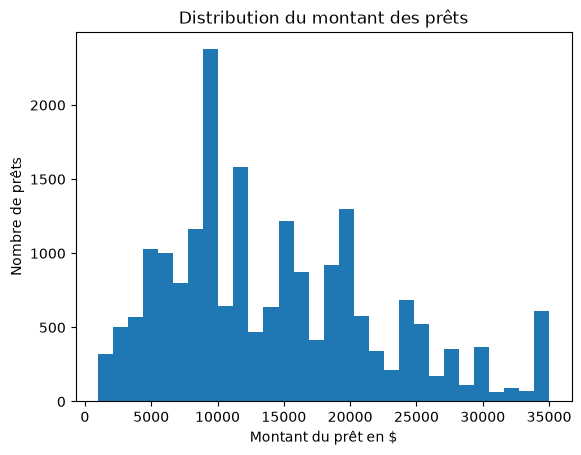

In [34]:
plt.hist(df["loan_amnt"], bins =30)
plt.xlabel("Montant du prêt en $")
plt.ylabel("Nombre de prêts")
plt.title("Distribution du montant des prêts")
plt.savefig("../reports/figures/distribution_loan_amount.pdf", bbox_inches="tight")
plt.show()

# Interprétation 

### La statisqtique descriptive montre que 20000 prêts ont été accordés. le montant moyen accordé est de 14411$. 50 % des prêts accordés sont supérieure ou égale à 12375$ et 50% sont inférieure ou égale à ce montant. le plus petit prêt accordé est de 1000$, le plus gros prët est de 35000$. Parailleurs 25% des prêts sont inférieures à 8325$ et 75% des prêts sont inférieures à 20000$. Le graphique montre une distribution asymétrique à droite. 

C:\Users\komla\AppData\Local\Temp\ipykernel_42924\2472801552.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["loan_amnt"], vert=False)


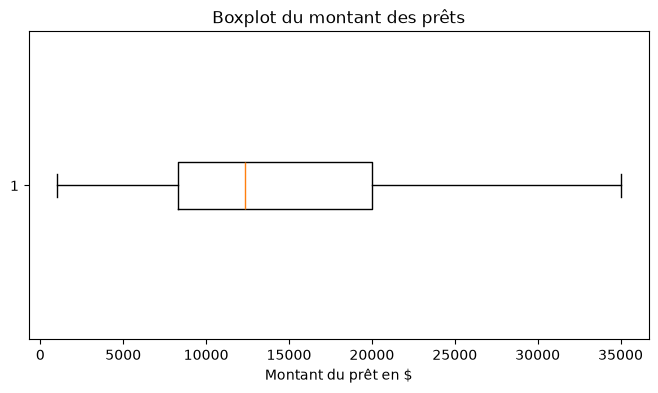

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.boxplot(df["loan_amnt"], vert=False)
plt.xlabel("Montant du prêt en $")
plt.title("Boxplot du montant des prêts")
plt.savefig("../reports/figures/boxplot_loan_amount.pdf", bbox_inches="tight")
plt.show()